#Mounting Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd /content/drive/MyDrive/33project/04.메디컬/03.MICCAI19-MedVQA

/content/drive/MyDrive/33project/04.메디컬/03.MICCAI19-MedVQA


#Installing Dependencies

In [3]:
# !pip3 install torch==0.4.21 # training wont work with newer versions of pytorch
!pip3 install fc

  Preparing metadata (setup.py) ... done
  Created wheel for fc: filename=fc-0.1.12-py3-none-any.whl size=5079 sha256=08c507829d8b507b379938718a2d7527904ba152c89baffc8aac90dc151e6bb7
  Stored in directory: /root/.cache/pip/wheels/71/58/1c/3c5893a4a12c7cc49e8b02996a520ad8547db0678543dc3d0b
Successfully built fc


#Importing Libraries

In [6]:
import os
import sys
import types
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import argparse
import time
import json

# ============================================================
# 최신 PyTorch 호환용
# 예전 코드에서 사용하는 torch._six를 임시로 만들어 줌
# ============================================================
if "torch._six" not in sys.modules:
    torch_six = types.ModuleType("torch._six")
    torch_six.string_classes = (str,)
    torch_six.int_classes = int
    sys.modules["torch._six"] = torch_six

# ============================================================
# 프로젝트 모듈 import
# ============================================================
from attention import BiAttention, StackedAttention
from language_model import WordEmbedding, QuestionEmbedding
from classifier import SimpleClassifier
from fc import FCNet
from bc import BCNet
from counting import Counter
from utils import tfidf_loading
from simple_cnn import SimpleCNN
from auto_encoder import Auto_Encoder_Model
from torch.utils.data import DataLoader, ConcatDataset

import dataset_RAD
import base_model
import utils

from train import train
from trainer import Trainer

from google.colab.patches import cv2_imshow

try:
    import _pickle as pickle
except ImportError:
    import pickle

#Defining Variables

In [7]:
dataset='data_RAD'
pretrain='saved_models/SAN_MEVF'
ae_model_path = 'pretrained_ae.pth'
epochs = 20
lr = 0.005
seed = 1204
model = "SAN"
rnn = "LSTM"
gamma = 2
gpu = 0
clip_norm = 0.25
num_stacks = 2
question_len = 12
eps_cnn = 1e-5
print_interval = 20
ae_alpha = 0.001
momentum_cnn = 0.05
tfidf = True
autoencoder = False
use_counter = False
op = 'c'
maml = False
RAD_dir = 'data_RAD'
output = 'saved_models/san_mevf'
activation = 'relu'
num_hid = 1024
maml_model_path = 'pretrained_maml.weights'
use_RAD = True
feat_dim = 64
batch_size = 32
dropout = 0.5
answer_types = ['CLOSED', 'OPEN', 'ALL']
quesntion_types = ['COUNT', 'COLOR', 'ORGAN', 'PRES', 'PLANE', 'MODALITY', 'POS', 'ABN', 'SIZE', 'OTHER', 'ATTRIB']

#Downloading Dataset

In [9]:
if os.path.exists(dataset) is False:
  print("Downloading Data")
  !gdown https://vision.aioz.io/f/777a3737ee904924bf0d/?dl=1
  !unzip ?dl=1 -d data_RAD
else:
  print('Dataset Already Downloaded')

Error:

	HTTPSConnectionPool(host='vision.aioz.io', port=443): Max retries
	exceeded with url: /f/777a3737ee904924bf0d/?dl=1 (Caused by
	SSLError(SSLError(1, '[SSL: TLSV1_ALERT_INTERNAL_ERROR] tlsv1 alert
	internal error (_ssl.c:1032)')))

To report issues, please visit https://github.com/wkentaro/gdown/issues.
unzip:  cannot find or open ?dl=1, ?dl=1.zip or ?dl=1.ZIP.

No zipfiles found.


#Downloading PreTrained Model

In [10]:
if os.path.exists(pretrain) is False:
  print("Downloading PreTrained Model")
  os.makedirs(pretrain, exist_ok=True)
  %cd saved_models/SAN_MEVF
  !gdown https://vision.aioz.io/f/fdc6572bc26f4dd684f4/?dl=1
  !mv ?dl=1 model_epoch19.pth
  %cd ../../
else:
  print('PreTrained Model Already Exists')

/content/drive/MyDrive/33project/04.메디컬/03.MICCAI19-MedVQA/saved_models/SAN_MEVF
Error:

	HTTPSConnectionPool(host='vision.aioz.io', port=443): Max retries
	exceeded with url: /f/fdc6572bc26f4dd684f4/?dl=1 (Caused by
	SSLError(SSLError(1, '[SSL: TLSV1_ALERT_INTERNAL_ERROR] tlsv1 alert
	internal error (_ssl.c:1032)')))

To report issues, please visit https://github.com/wkentaro/gdown/issues.
mv: cannot stat '?dl=1': No such file or directory
/content/drive/MyDrive/33project/04.메디컬/03.MICCAI19-MedVQA


#Defining SAN Model

In [11]:
# Create SAN model
class SAN_Model(nn.Module):
    def __init__(self, w_emb, q_emb, v_att, classifier, args, maml_v_emb, ae_v_emb):
        super(SAN_Model, self).__init__()
        self.args = args
        self.w_emb = w_emb
        self.q_emb = q_emb
        self.v_att = v_att
        self.classifier = classifier
        if args.maml:
            self.maml_v_emb = maml_v_emb
        if args.autoencoder:
            self.ae_v_emb = ae_v_emb
            self.convert = nn.Linear(16384, 64)
    def forward(self, v, q):
        """Forward

        v: [batch, num_objs, obj_dim]
        b: [batch, num_objs, b_dim]
        q: [batch_size, seq_length]

        return: logits, not probs
        """
        # get visual feature
        if self.args.maml:
            maml_v_emb = self.maml_v_emb(v[0]).unsqueeze(1)
            v_emb = maml_v_emb
        if self.args.autoencoder:
            encoder = self.ae_v_emb.forward_pass(v[1])
            decoder = self.ae_v_emb.reconstruct_pass(encoder)
            ae_v_emb = encoder.view(encoder.shape[0], -1)
            ae_v_emb = self.convert(ae_v_emb).unsqueeze(1)
            v_emb = ae_v_emb
        if self.args.maml and self.args.autoencoder:
            v_emb = torch.cat((maml_v_emb, ae_v_emb), 2)
        # get textual feature
        w_emb = self.w_emb(q)
        q_emb = self.q_emb(w_emb)  # [batch, q_dim], return final hidden state
        # Attention
        att = self.v_att(v_emb, q_emb)
        if self.args.autoencoder:
            return att, decoder
        return att

    def classify(self, input_feats):
        return self.classifier(input_feats)

# Build SAN model
def build_SAN(dataset, args):
    # init word embedding module, question embedding module, and Attention network
    w_emb = WordEmbedding(dataset.dictionary.ntoken, 300, 0.0, args.op)
    q_emb = QuestionEmbedding(300 if 'c' not in args.op else 600, args.num_hid, 1, False, 0.0, args.rnn)
    v_att = StackedAttention(args.num_stacks, dataset.v_dim, args.num_hid, args.num_hid, dataset.num_ans_candidates,
                             args.dropout)
    # build and load pre-trained MAML model
    if args.maml:
        weight_path = args.RAD_dir + '/' + args.maml_model_path
        print('load initial weights MAML from: %s' % (weight_path))
        maml_v_emb = SimpleCNN(weight_path, args.eps_cnn, args.momentum_cnn)
    # build and load pre-trained Auto-encoder model
    if args.autoencoder:
        ae_v_emb = Auto_Encoder_Model()
        weight_path = args.RAD_dir + '/' + args.ae_model_path
        print('load initial weights DAE from: %s'%(weight_path))
        ae_v_emb.load_state_dict(torch.load(weight_path))
    # Loading tfidf weighted embedding
    if hasattr(args, 'tfidf'):
        w_emb = tfidf_loading(args.tfidf, w_emb, args)
    # init classifier
    classifier = SimpleClassifier(
        args.num_hid, 2 * args.num_hid, dataset.num_ans_candidates, args)
    # contruct VQA model and return
    if args.maml and args.autoencoder:
        return SAN_Model(w_emb, q_emb, v_att, classifier, args, maml_v_emb, ae_v_emb)
    elif args.maml:
        return SAN_Model(w_emb, q_emb, v_att, classifier, args, maml_v_emb, None)
    elif args.autoencoder:
        return SAN_Model(w_emb, q_emb, v_att, classifier, args, None, ae_v_emb)
    return SAN_Model(w_emb, q_emb, v_att, classifier, args, None, None)

#Training

In [12]:
warmup_updates = 4000

# Kaiming normalization initialization
def init_weights(m):
    if type(m) == nn.Linear:
        with torch.no_grad():
            torch.nn.init.kaiming_normal_(m.weight)

# VQA score computation
def compute_score_with_logits(logits, labels):
    logits = torch.max(logits, 1)[1].data # argmax
    one_hots = torch.zeros(*labels.size()).to(logits.device)
    one_hots.scatter_(1, logits.view(-1, 1), 1)
    scores = (one_hots * labels)
    return scores

# Train phase
def train(args, model, train_loader, eval_loader, num_epochs, output, opt=None, s_epoch=0):
    device = args.device
    # Scheduler learning rate
    lr_default = args.lr
    lr_decay_step = 2
    lr_decay_rate = .75
    lr_decay_epochs = range(10,20,lr_decay_step) if eval_loader is not None else range(10,20,lr_decay_step)
    gradual_warmup_steps = [0.5 * lr_default, 1.0 * lr_default, 1.5 * lr_default, 2.0 * lr_default]
    saving_epoch = 15    # Start point for model saving
    grad_clip = args.clip_norm

    utils.create_dir(output)

    # Adamax optimizer
    optim = torch.optim.Adamax(filter(lambda p: p.requires_grad, model.parameters()), lr=lr_default) \
        if opt is None else opt

    # Loss function
    criterion = torch.nn.BCEWithLogitsLoss(reduction='sum')
    ae_criterion = torch.nn.MSELoss()

    # write hyper-parameter to log file
    logger = utils.Logger(os.path.join(output, 'log.txt'))
    logger.write(args.__repr__())
    utils.print_model(model, logger)
    logger.write('optim: adamax lr=%.4f, decay_step=%d, decay_rate=%.2f, grad_clip=%.2f' % \
        (lr_default, lr_decay_step, lr_decay_rate, grad_clip))

    # create trainer
    trainer = Trainer(args, model, criterion, optim, ae_criterion)
    update_freq = int(args.update_freq)
    wall_time_start = time.time()

    best_eval_score = 0
    # Epoch passing in training phase
    for epoch in range(s_epoch, num_epochs):
        total_loss = 0
        train_score = 0
        total_norm = 0
        count_norm = 0
        num_updates = 0
        t = time.time()
        N = len(train_loader.dataset)
        num_batches = int(N/args.batch_size + 1)
        if epoch < len(gradual_warmup_steps):
            trainer.optimizer.param_groups[0]['lr'] = gradual_warmup_steps[epoch]
            logger.write('gradual warm up lr: %.4f' % trainer.optimizer.param_groups[0]['lr'])
        elif epoch in lr_decay_epochs:
            trainer.optimizer.param_groups[0]['lr'] *= lr_decay_rate
            logger.write('decreased lr: %.4f' % trainer.optimizer.param_groups[0]['lr'])
        else:
            logger.write('lr: %.4f' % trainer.optimizer.param_groups[0]['lr'])

        # Predicting and computing score
        for i, (v, q, a, _, _, _) in enumerate(train_loader):
            if args.maml:
                v[0] = v[0].reshape(v[0].shape[0], 84, 84).unsqueeze(1)
            if args.autoencoder:
                v[1] = v[1].reshape(v[1].shape[0], 128, 128).unsqueeze(1)
            v[0] = v[0].to(device)
            v[1] = v[1].to(device)
            q = q.to(device)
            a = a.to(device)
            sample = [v, q, a]

            if i < num_batches - 1 and (i + 1) % update_freq > 0:
                trainer.train_step(sample, update_params=False)
            else:
                loss, grad_norm, batch_score = trainer.train_step(sample, update_params=True)
                total_norm += grad_norm
                count_norm += 1

                total_loss += loss.item()
                train_score += batch_score
                num_updates += 1
                if num_updates % int(args.print_interval / update_freq) == 0:
                    print("Iter: {}, Loss {:.4f}, Norm: {:.4f}, Total norm: {:.4f}, Num updates: {}, Wall time: {:.2f}, ETA: {}".format(i + 1, total_loss / ((num_updates + 1)), grad_norm, total_norm, num_updates, time.time() - wall_time_start, utils.time_since(t, i / num_batches)))

        total_loss /= num_updates
        train_score = 100 * train_score / (num_updates * args.batch_size)

        # Evaluation
        if eval_loader is not None:
            print("Evaluating...")
            trainer.model.train(False)
            eval_score, bound = evaluate(model, eval_loader, args)
            trainer.model.train(True)

        logger.write('epoch %d, time: %.2f' % (epoch, time.time()-t))
        logger.write('\ttrain_loss: %.2f, norm: %.4f, score: %.2f' % (total_loss, total_norm/count_norm, train_score))
        if eval_loader is not None:
            logger.write('\teval score: %.2f (%.2f)' % (100 * eval_score, 100 * bound))

        # Save per epoch
        if epoch >= saving_epoch:
            model_path = os.path.join(output, 'model_epoch%d.pth' % epoch)
            utils.save_model(model_path, model, epoch, trainer.optimizer)
            # Save best epoch
            if eval_loader is not None and eval_score > best_eval_score:
                model_path = os.path.join(output, 'model_epoch_best.pth')
                utils.save_model(model_path, model, epoch, trainer.optimizer)
                best_eval_score = eval_score

In [13]:
'''
Training will ONLY work with torch==0.4.1 which can not be installed in colab
as it requires python 3.6.0, and colab doesnt support old python versions
anymore. It is thus recomended to use this notebook in jupyter notebook running on local system
See requirements.txt for complete installed packages.

'''
'''
If you get the following ERROR during training:
RuntimeError: one of the variables needed for gradient computation has been modified by an inplace operation:
[torch.cuda.FloatTensor [32, 2048]], which is output 0 of ReluBackward0.
Then install torch==0.4.1 and rerun entire notebook it.

'''
utils.create_dir(output)
# logger = utils.Logger(os.path.join(output, 'log.txt'))
# logger.write(args.__repr__())


def parse_args():
    # Return args
    with open('args_training.json', 'r') as f:
      args_dict = json.load(f)
    return argparse.Namespace(**args_dict)

args = parse_args()

# Set GPU device
device = torch.device("cuda:" + str(gpu) if gpu >= 0 else "cpu")
args.device = device

# Fixed ramdom seed
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = True
# Load dictionary and RAD training dataset
if use_RAD:
    dictionary = dataset_RAD.Dictionary.load_from_file(os.path.join(RAD_dir, 'dictionary.pkl'))
    train_dset = dataset_RAD.VQAFeatureDataset('train',args, dictionary, question_len=question_len)
batch_size = batch_size
# Create VQA model
constructor = 'build_%s' % model
model = getattr(base_model, constructor)(train_dset, args)
optim = None
epoch = 0

# create training dataloader
train_loader = DataLoader(train_dset, batch_size, shuffle=True, num_workers=0, collate_fn=utils.trim_collate, pin_memory=True)
eval_loader = None
# training phase
train(args,model, train_loader, eval_loader, epochs, output, optim, epoch)

loading dictionary from data_RAD/dictionary.pkl


FileNotFoundError: [Errno 2] No such file or directory: 'data_RAD/dictionary.pkl'

#Inference

loading dictionary from data_RAD/dictionary.pkl
loading MAML image data from file: data_RAD/images84x84.pkl
loading DAE image data from file: data_RAD/images128x128.pkl
load initial weights MAML from: data_RAD/pretrained_maml.weights
load initial weights DAE from: data_RAD/pretrained_ae.pth
loading saved_models/SAN_MEVF/model_epoch19.pth


/content/drive/MyDrive/MICCAI19-MedVQA/utils.py:140: UserWarning: An output with one or more elements was resized since it had shape [7056], which does not match the required output shape [1, 7056]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at ../aten/src/ATen/native/Resize.cpp:17.)
  return torch.stack(batch, 0, out=out)
/content/drive/MyDrive/MICCAI19-MedVQA/utils.py:140: UserWarning: An output with one or more elements was resized since it had shape [16384], which does not match the required output shape [1, 16384]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at ../aten/src/ATen/native/

Question_1 : is there evidence of an aortic aneurysm _ _ _ _ _
Predicted Answer : no


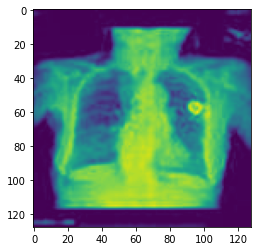

Question_2 : is there hypo-dense consolidation on the left side _ _ _ _
Predicted Answer : no


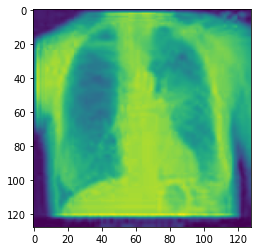

Question_3 : is this an axial plane _ _ _ _ _ _ _
Predicted Answer : yes


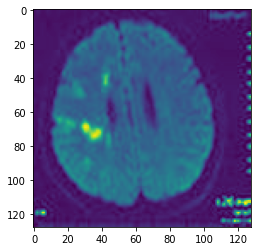

In [ ]:
# def load_args(filename):
#     with open(filename, 'r') as f:
#         args_dict = json.load(f)
#     args = argparse.Namespace(**args_dict)
#     return args

def compute_score_with_logits(logits, labels):
    logits = torch.max(logits, 1)[1].data  # argmax
    one_hots = torch.zeros(*labels.size()).to(logits.device)
    one_hots.scatter_(1, logits.view(-1, 1), 1)
    scores = (one_hots * labels)
    return scores

def parse_args():
    # Return args
    with open('args_infer.json', 'r') as f:
      args_dict = json.load(f)
    return argparse.Namespace(**args_dict)
# Load questions
def get_question(q, dataloader):
    q = q.squeeze(0)
    str = []
    dictionary = dataloader.dataset.dictionary
    for i in range(q.size(0)):
        str.append(dictionary.idx2word[q[i]] if q[i] < len(dictionary.idx2word) else '_')
    return ' '.join(str)

# Load answers
def get_answer(p, dataloader):
    _m, idx = p.max(1)
    return dataloader.dataset.label2ans[idx.item()]

# Logit computation (for train, test or evaluate)
def get_result(model, dataloader, device, args):
    keys = ['count', 'real', 'true', 'real_percent', 'score', 'score_percent']
    question_types_result = dict((i, dict((j, dict((k, 0.0) for k in keys)) for j in quesntion_types)) for i in answer_types)
    result = dict((i, dict((j, 0.0) for j in keys)) for i in answer_types)
    counter=0
    with torch.no_grad():
        for v, q, a, ans_type, q_types, p_type in iter(dataloader):
            counter+=1

            if counter==4:
              break

            print(f'Question_{counter} :',get_question(q,dataloader))

            if p_type[0] != "freeform":
                continue

            if args.maml:
                v[0] = v[0].reshape(v[0].shape[0], 84, 84).unsqueeze(1)

            if args.autoencoder:
                v[1] = v[1].reshape(v[1].shape[0], 128, 128).unsqueeze(1)
                d= np.copy(v[1])

            v[0] = v[0].to(device)
            v[1] = v[1].to(device)
            q = q.to(device)
            a = a.to(device)
            # inference and get logit
            if args.autoencoder:
                features, _ = model(v, q)
            else:
                features = model(v, q)
            preds = model.classifier(features)
            final_preds = preds
            print(f'Predicted Answer :',get_answer(final_preds,dataloader))
            plt.imshow((d[0][0]))
            plt.show()
            batch_score = compute_score_with_logits(final_preds, a.data).sum()

    return

# Test phase

args = parse_args()

torch.backends.cudnn.benchmark = True
args.device = torch.device("cuda:" + str(args.gpu) if args.gpu >= 0 else "cpu")

# Check if evaluating on TDIUC dataset or VQA dataset
if args.use_RAD:
    dictionary = dataset_RAD.Dictionary.load_from_file(os.path.join(args.RAD_dir , 'dictionary.pkl'))
    eval_dset = dataset_RAD.VQAFeatureDataset(args.split, args, dictionary)

batch_size = args.batch_size

constructor = 'build_%s' % args.model
model = getattr(base_model, constructor)(eval_dset, args)

eval_loader = DataLoader(eval_dset, batch_size, shuffle=False, num_workers=0, pin_memory=True, collate_fn=utils.trim_collate)

def save_questiontype_results(outfile_path, quesntion_types_result):
    for i in quesntion_types_result:
        pd.DataFrame(quesntion_types_result[i]).transpose().to_csv(outfile_path + '/question_type_' + i + '.csv')
# Testing process
def process(args, model, eval_loader):
    model_path = args.input + '/model_epoch%s.pth' % args.epoch
    print('loading %s' % model_path)
    model_data = torch.load(model_path)

    # Comment because do not use multi gpu
    # model = nn.DataParallel(model)
    model = model.to(args.device)
    model.load_state_dict(model_data.get('model_state', model_data))

    model.train(False)
    if not os.path.exists(args.output):
        os.makedirs(args.output)
    if args.use_RAD:
        get_result(model, eval_loader, args.device, args)

    return
process(args, model, eval_loader)
